# Tool Menu Overload: Measuring Tool-Use Regression in an LLM Agent (14 vs 17 tools)

This notebook demonstrates **empirical tool-use degradation** when the **tool menu grows** but tasks are unchanged.

**Primary question:** Does performance drop on old tasks when the tool menu increases from **14 → 17**?

**What “problematic” means here:**

- Lower task success rate on the old-suite
- New-tool intrusion (calls to new tools that aren’t needed)
- Tool confusion (selecting overlapping tools)
- Sequence breaks (wrong order)
- Schema/argument errors
- Extra tool calls (cost/latency)


## 1) Setup

This notebook uses a **real LLM tool-calling loop**: the model chooses tools, you execute deterministic simulator functions, then you feed tool outputs back to the model until it finishes or hits a step limit.

Authentication uses **Entra ID** via `az login` and `DefaultAzureCredential`.


In [45]:
# Install once if needed:
# %pip install openai pandas numpy tqdm matplotlib jsonschema scipy python-dotenv azure-identity

import os
import json
import math
import random
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Tuple
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from jsonschema import validate, ValidationError
from tqdm import tqdm
from dotenv import load_dotenv
from azure.identity import DefaultAzureCredential

from openai import AzureOpenAI

In [42]:
# Load environment variables from .env
load_dotenv()

# Config
AZURE_OPENAI_ENDPOINT = os.environ["AZURE_OPENAI_ENDPOINT"]
# Responses API requires 2025-03-01-preview or later
AZURE_OPENAI_API_VERSION = "2025-03-01-preview"
AZURE_OPENAI_DEPLOYMENT = os.environ["AZURE_OPENAI_DEPLOYMENT"]

MODEL = AZURE_OPENAI_DEPLOYMENT
TEMPERATURE = 0.0
N_TASKS = 20  # full experiment
TRIALS_PER_TASK = 3  # full experiment
MAX_AGENT_STEPS = 12

TOOL_MENU_CONDITIONS = [
    "menu14",
    "menu17_irrelevant",
    "menu17_overlapping",
]

SHUFFLE_TOOL_ORDER = [False, True]  # full experiment
STRICT_SCHEMA = [True, False]  # full experiment

RANDOM_SEED = 7
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 2) Scenario + simulator

**Scenario:** “Customer Visit Trip + Calendar Coordination” with dependency chains:

- `book_flight` requires a `flight_id` from `search_flights`
- `book_hotel` requires a `hotel_id` from `search_hotels`
- `create_calendar_event` must not overlap busy blocks
- `send_email` should include a simple itinerary summary (lightly validated)


In [3]:
@dataclass
class Flight:
    flight_id: str
    origin: str
    destination: str
    depart: str
    arrive: str
    price: int


@dataclass
class Hotel:
    hotel_id: str
    city: str
    name: str
    nightly_rate: int


@dataclass
class WorldState:
    flights: List[Flight] = field(default_factory=list)
    hotels: List[Hotel] = field(default_factory=list)
    booked_flight_id: Optional[str] = None
    booked_hotel_id: Optional[str] = None
    calendar_events: List[Dict[str, Any]] = field(default_factory=list)
    sent_emails: List[Dict[str, Any]] = field(default_factory=list)
    last_flight_search_ids: List[str] = field(default_factory=list)
    last_hotel_search_ids: List[str] = field(default_factory=list)
    busy_blocks: List[Tuple[str, str]] = field(default_factory=list)


In [4]:
# Deterministic data
FLIGHTS = [
    Flight("FL1", "SFO", "SEA", "2025-04-08T09:00", "2025-04-08T11:00", 320),
    Flight("FL2", "SFO", "SEA", "2025-04-08T12:00", "2025-04-08T14:00", 410),
    Flight("FL3", "SFO", "SEA", "2025-04-08T16:00", "2025-04-08T18:00", 280),
]

HOTELS = [
    Hotel("HT1", "SEA", "Pike Place Inn", 190),
    Hotel("HT2", "SEA", "Lake Union Suites", 220),
]


In [5]:
# Tool implementations

def get_user_profile():
    return {"home_airport": "SFO", "preferences": {"seat": "aisle"}}


def get_calendar(date_range: Tuple[str, str], state: WorldState):
    return {"busy": state.busy_blocks}


def search_flights(origin: str, destination: str, depart_date: str, return_date: str, constraints: Dict, state: WorldState):
    matches = [f for f in state.flights if f.origin == origin and f.destination == destination]
    state.last_flight_search_ids = [f.flight_id for f in matches]
    return {"results": [f.__dict__ for f in matches]}


def book_flight(flight_id: str, traveler_info: Dict, state: WorldState):
    if flight_id not in state.last_flight_search_ids:
        return {"error": "flight_id not in prior search results"}
    state.booked_flight_id = flight_id
    return {"booked_flight_id": flight_id}


def search_hotels(city: str, checkin: str, checkout: str, constraints: Dict, state: WorldState):
    matches = [h for h in state.hotels if h.city == city]
    state.last_hotel_search_ids = [h.hotel_id for h in matches]
    return {"results": [h.__dict__ for h in matches]}


def book_hotel(hotel_id: str, guest_info: Dict, state: WorldState):
    if hotel_id not in state.last_hotel_search_ids:
        return {"error": "hotel_id not in prior search results"}
    state.booked_hotel_id = hotel_id
    return {"booked_hotel_id": hotel_id}


def create_calendar_event(title: str, start: str, end: str, attendees: List[str], location: str, state: WorldState):
    for busy_start, busy_end in state.busy_blocks:
        if not (end <= busy_start or start >= busy_end):
            return {"error": "time overlaps with busy block"}
    event = {"title": title, "start": start, "end": end, "attendees": attendees, "location": location}
    state.calendar_events.append(event)
    return {"event_id": f"EV{len(state.calendar_events)}"}


def send_email(to: str, subject: str, body: str, state: WorldState):
    msg = {"to": to, "subject": subject, "body": body}
    state.sent_emails.append(msg)
    return {"status": "sent"}


## 3) Task generation (old-suite)

These tasks **do not require** the 3 new tools added in the 17-tool conditions.


In [43]:
def make_task(task_id: int) -> Dict[str, Any]:
    return {
        "task_id": f"trip_{task_id:03d}",
        "prompt": (
            "Plan my 2-day trip to visit Customer X in Seattle next week. "
            "I need a flight that arrives before 3pm local time on Day 1, "
            "a hotel near the customer site, schedule two 45-minute meetings "
            "with their team within my free slots, and email my manager the final itinerary."
        ),
        "constraints": {
            "arrive_by": "15:00",
            "meeting_count": 2,
        },
    }


def build_tasks(n: int) -> List[Dict[str, Any]]:
    return [make_task(i) for i in range(n)]

TASKS = build_tasks(N_TASKS)


## 4) Tool menus (14 vs 17)

Only the tool **menu** changes; the tasks and simulator stay identical.


In [7]:
BASE_TOOLS = [
    "get_user_profile",
    "get_calendar",
    "search_flights",
    "book_flight",
    "search_hotels",
    "book_hotel",
    "create_calendar_event",
    "send_email",
    "get_weather",
    "get_travel_time",
    "lookup_company_policy",
    "search_restaurants",
    "create_expense_report_draft",
    "summarize_text",
]

IRRELEVANT_NEW_TOOLS = [
    "dv_sync_assets",
    "dv_generate_dashboard",
    "dv_export_dataset",
]

OVERLAPPING_NEW_TOOLS = [
    "search_flights_v2",
    "book_reservation",
    "send_message",
]


def menu_tools(condition: str) -> List[str]:
    if condition == "menu14":
        return BASE_TOOLS
    if condition == "menu17_irrelevant":
        return BASE_TOOLS + IRRELEVANT_NEW_TOOLS
    if condition == "menu17_overlapping":
        return BASE_TOOLS + OVERLAPPING_NEW_TOOLS
    raise ValueError(f"unknown condition: {condition}")


## 5) Tool schemas (strict vs non-strict)

Each tool is defined with a JSON schema. When `STRICT_SCHEMA=True`, the schemas are enforced.


In [25]:
TOOL_SCHEMAS = {
    "get_user_profile": {
        "type": "object",
        "properties": {},
        "additionalProperties": False,
    },
    "get_calendar": {
        "type": "object",
        "properties": {
            "date_range": {
                "type": "array",
                "items": {"type": "string"},
                "minItems": 2,
                "maxItems": 2,
            }
        },
        "required": ["date_range"],
        "additionalProperties": False,
    },
    "search_flights": {
        "type": "object",
        "properties": {
            "origin": {"type": "string"},
            "destination": {"type": "string"},
            "depart_date": {"type": "string"},
            "return_date": {"type": "string"},
            "constraints": {"type": "object", "properties": {}, "additionalProperties": False},
        },
        "required": ["origin", "destination", "depart_date", "return_date", "constraints"],
        "additionalProperties": False,
    },
    "book_flight": {
        "type": "object",
        "properties": {
            "flight_id": {"type": "string"},
            "traveler_info": {"type": "object", "properties": {}, "additionalProperties": False},
        },
        "required": ["flight_id", "traveler_info"],
        "additionalProperties": False,
    },
    "search_hotels": {
        "type": "object",
        "properties": {
            "city": {"type": "string"},
            "checkin": {"type": "string"},
            "checkout": {"type": "string"},
            "constraints": {"type": "object", "properties": {}, "additionalProperties": False},
        },
        "required": ["city", "checkin", "checkout", "constraints"],
        "additionalProperties": False,
    },
    "book_hotel": {
        "type": "object",
        "properties": {
            "hotel_id": {"type": "string"},
            "guest_info": {"type": "object", "properties": {}, "additionalProperties": False},
        },
        "required": ["hotel_id", "guest_info"],
        "additionalProperties": False,
    },
    "create_calendar_event": {
        "type": "object",
        "properties": {
            "title": {"type": "string"},
            "start": {"type": "string"},
            "end": {"type": "string"},
            "attendees": {"type": "array", "items": {"type": "string"}},
            "location": {"type": "string"},
        },
        "required": ["title", "start", "end", "attendees", "location"],
        "additionalProperties": False,
    },
    "send_email": {
        "type": "object",
        "properties": {
            "to": {"type": "string"},
            "subject": {"type": "string"},
            "body": {"type": "string"},
        },
        "required": ["to", "subject", "body"],
        "additionalProperties": False,
    },
}

In [28]:
# Tool definitions for the LLM

def tool_definitions(tool_names: List[str], strict: bool) -> List[Dict[str, Any]]:
    default_schema = {"type": "object", "properties": {}, "additionalProperties": False}
    defs = []
    for name in tool_names:
        schema = TOOL_SCHEMAS.get(name, default_schema)
        defs.append({
            "type": "function",
            "name": name,
            "description": f"Tool: {name}",
            "parameters": schema,
            "strict": strict,
        })
    return defs

## 6) Entra ID auth and Azure OpenAI client

Use `az login` locally, then run this cell to use your Entra ID token.


In [46]:
AZURE_SCOPE = "https://cognitiveservices.azure.com/.default"

# Cache credential globally to avoid repeated initialization
_cached_credential = None
_cached_client = None

def get_azure_client() -> AzureOpenAI:
    global _cached_credential, _cached_client
    if _cached_client is None:
        _cached_credential = DefaultAzureCredential()
        token_provider = lambda: _cached_credential.get_token(AZURE_SCOPE).token
        _cached_client = AzureOpenAI(
            azure_endpoint=AZURE_OPENAI_ENDPOINT,
            api_version=AZURE_OPENAI_API_VERSION,
            azure_ad_token_provider=token_provider,
        )
    return _cached_client

## 7) LLM tool-calling loop

This loop is the core: the **LLM orchestrates** tool selection, arguments, and sequencing.


In [36]:
@dataclass
class ToolCall:
    name: str
    args: Dict[str, Any]


@dataclass
class EpisodeLog:
    task_id: str
    condition: str
    seed: int
    strict_schema: bool
    tool_order_shuffled: bool
    tool_list: List[str]
    tool_calls: List[ToolCall]
    tool_responses: List[Dict[str, Any]]
    success: bool
    failure_reason: Optional[str]


def execute_tool(call: ToolCall, state: WorldState) -> Dict[str, Any]:
    try:
        if call.name == "get_user_profile":
            return get_user_profile()
        if call.name == "get_calendar":
            date_range = call.args.get("date_range", ["2025-04-08", "2025-04-10"])
            return get_calendar(tuple(date_range), state)
        if call.name == "search_flights":
            return search_flights(state=state, **call.args)
        if call.name == "book_flight":
            return book_flight(state=state, **call.args)
        if call.name == "search_hotels":
            return search_hotels(state=state, **call.args)
        if call.name == "book_hotel":
            return book_hotel(state=state, **call.args)
        if call.name == "create_calendar_event":
            return create_calendar_event(state=state, **call.args)
        if call.name == "send_email":
            return send_email(state=state, **call.args)
        return {"error": f"tool {call.name} not implemented in simulator"}
    except Exception as e:
        return {"error": f"tool execution error: {str(e)}"}


def run_agent_episode(task: Dict[str, Any], condition: str, seed: int, strict: bool, shuffle_tools: bool) -> EpisodeLog:
    rng = random.Random(seed)
    state = WorldState(flights=FLIGHTS, hotels=HOTELS, busy_blocks=[("2025-04-08T15:30", "2025-04-08T16:30")])

    tools = menu_tools(condition)
    if shuffle_tools:
        tools = tools.copy()
        rng.shuffle(tools)

    client = get_azure_client()
    tool_defs = tool_definitions(tools, strict)

    system_prompt = (
        "You are a planning assistant. You must use tools to complete the task. "
        "Call tools in a valid order: search before booking; check calendar before scheduling. "
        "Return a concise final message after completing tool calls."
    )

    tool_calls_list = []
    tool_responses = []
    success = False
    failure_reason = None
    
    # First call with user input
    response = client.responses.create(
        model=MODEL,
        instructions=system_prompt,
        input=task["prompt"],
        tools=tool_defs,
        temperature=TEMPERATURE,
    )

    for _ in range(MAX_AGENT_STEPS):
        step_tool_calls = [item for item in response.output if item.type == "function_call"]
        if not step_tool_calls:
            success = True
            break

        # Collect function call outputs for next iteration
        function_outputs = []
        for call in step_tool_calls:
            # Parse arguments - they may be a JSON string
            args = call.arguments
            if isinstance(args, str):
                try:
                    args = json.loads(args)
                except json.JSONDecodeError:
                    args = {}
            args = args or {}
            
            tool_call = ToolCall(name=call.name, args=args)
            tool_calls_list.append(tool_call)

            if strict and call.name in TOOL_SCHEMAS:
                try:
                    validate(instance=args, schema=TOOL_SCHEMAS[call.name])
                except ValidationError as err:
                    tool_responses.append({"error": f"schema_error: {err.message}"})
                    function_outputs.append({
                        "type": "function_call_output",
                        "call_id": call.call_id,
                        "output": json.dumps({"error": "schema_error"}),
                    })
                    continue

            output = execute_tool(tool_call, state)
            tool_responses.append(output)
            function_outputs.append({
                "type": "function_call_output",
                "call_id": call.call_id,
                "output": json.dumps(output),
            })

        # Continue conversation with previous_response_id and function outputs
        response = client.responses.create(
            model=MODEL,
            previous_response_id=response.id,
            input=function_outputs,
            tools=tool_defs,
            temperature=TEMPERATURE,
        )

    if not success and failure_reason is None:
        failure_reason = "max_steps"

    return EpisodeLog(
        task_id=task["task_id"],
        condition=condition,
        seed=seed,
        strict_schema=strict,
        tool_order_shuffled=shuffle_tools,
        tool_list=tools,
        tool_calls=tool_calls_list,
        tool_responses=tool_responses,
        success=success,
        failure_reason=failure_reason,
    )

## 8) Metrics

We measure task success and tool-use degradations specific to the 14 → 17 regression.


In [37]:
NEW_TOOL_SETS = {
    "menu17_irrelevant": set(IRRELEVANT_NEW_TOOLS),
    "menu17_overlapping": set(OVERLAPPING_NEW_TOOLS),
}

EQUIVALENCE_MAP = {
    "search_flights_v2": "search_flights",
    "book_reservation": "book_flight",
    "send_message": "send_email",
}


def score_episode(log: EpisodeLog) -> Dict[str, Any]:
    tool_names = [c.name for c in log.tool_calls]
    new_tools = NEW_TOOL_SETS.get(log.condition, set())
    new_tool_intrusion = any(name in new_tools for name in tool_names)

    tool_confusion = any(
        (name in EQUIVALENCE_MAP and EQUIVALENCE_MAP[name] in BASE_TOOLS)
        for name in tool_names
    )

    return {
        "task_id": log.task_id,
        "condition": log.condition,
        "seed": log.seed,
        "strict_schema": log.strict_schema,
        "tool_order_shuffled": log.tool_order_shuffled,
        "success": log.success,
        "failure_reason": log.failure_reason or "",
        "tool_calls": len(log.tool_calls),
        "new_tool_intrusion": new_tool_intrusion,
        "tool_confusion": tool_confusion,
    }


## 9) Run the experiment

This runs the agent loop and logs results across tool menus.


In [47]:
# Warning: this will call the model and incur cost.
# Parallelized version using ThreadPoolExecutor

MAX_WORKERS = 8  # Adjust based on rate limits and available resources

def run_single_experiment(args):
    """Wrapper function for parallel execution."""
    task, condition, seed, strict, shuffle_tools = args
    try:
        log = run_agent_episode(task, condition, seed, strict, shuffle_tools)
        return score_episode(log)
    except Exception as e:
        # Return a failed result on error
        return {
            "task_id": task["task_id"],
            "condition": condition,
            "seed": seed,
            "strict_schema": strict,
            "tool_order_shuffled": shuffle_tools,
            "success": False,
            "failure_reason": f"error: {str(e)}",
            "tool_calls": 0,
            "new_tool_intrusion": False,
            "tool_confusion": False,
        }

# Build list of all experiment configurations
experiment_args = [
    (task, condition, RANDOM_SEED + trial, strict, shuffle_tools)
    for task in TASKS
    for condition in TOOL_MENU_CONDITIONS
    for strict in STRICT_SCHEMA
    for shuffle_tools in SHUFFLE_TOOL_ORDER
    for trial in range(TRIALS_PER_TASK)
]

print(f"Running {len(experiment_args)} experiments with {MAX_WORKERS} parallel workers...")

# Run experiments in parallel
results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(run_single_experiment, args): args for args in experiment_args}
    for future in tqdm(as_completed(futures), total=len(futures)):
        results.append(future.result())

df = pd.DataFrame(results)
print(f"Completed {len(df)} experiments")
df.head()

Running 720 experiments with 8 parallel workers...


  0%|          | 0/720 [00:00<?, ?it/s]

100%|██████████| 720/720 [24:17<00:00,  2.02s/it]

Completed 720 experiments


,task_id,condition,seed,strict_schema,tool_order_shuffled,success,failure_reason,tool_calls,new_tool_intrusion,tool_confusion
0,trip_000,menu14,8,True,False,True,,1,False,False
1,trip_000,menu14,7,False,False,True,,1,False,False
2,trip_000,menu14,8,False,False,True,,1,False,False
3,trip_000,menu14,9,True,True,True,,2,False,False
4,trip_000,menu14,9,True,False,True,,1,False,False


## 10) Summaries + plots

These charts directly answer the 14 → 17 regression question.


In [48]:
# Example aggregation (replace with real results)
summary = df.groupby(["condition"]).agg(
    success_rate=("success", "mean"),
    new_tool_intrusion=("new_tool_intrusion", "mean"),
    tool_confusion=("tool_confusion", "mean"),
    avg_tool_calls=("tool_calls", "mean"),
).reset_index()

summary


,condition,success_rate,new_tool_intrusion,tool_confusion,avg_tool_calls
0,menu14,0.958333,0.0,0.0,2.766667
1,menu17_irrelevant,0.995833,0.0,0.0,2.691667
2,menu17_overlapping,0.983333,0.0,0.0,1.950000


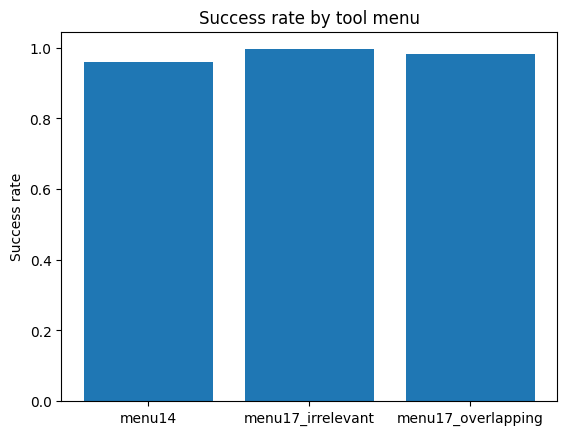

In [49]:
# Example plot scaffold
fig, ax = plt.subplots()
ax.bar(summary["condition"], summary["success_rate"])
ax.set_title("Success rate by tool menu")
ax.set_ylabel("Success rate")
plt.show()


## 11) Decision gate

Example policy:

- Block shipping if success drops ≥ 2 points on old-suite, OR
- new-tool intrusion exceeds 1% on old-suite, OR
- wrong-tool rate increases ≥ X%


In [50]:
def decision_gate(success_drop: float, new_tool_intrusion: float, wrong_tool_increase: float) -> str:
    if success_drop >= 0.02 or new_tool_intrusion > 0.01 or wrong_tool_increase >= 0.02:
        return "BLOCK"
    return "SHIP"

print(decision_gate(success_drop=0.03, new_tool_intrusion=0.012, wrong_tool_increase=0.01))


BLOCK
